# Step 3 - When is the car accelerating, braking, and coasting?
> Give a time frame for when the car is accelerating, braking, and coasting. Explain how you found these values out. Then plot those states over time on three different graphs.

In [2]:
import polars as pL
import numpy as np
import matplotlib.pyplot as plt

pd = pL.read_parquet("../software-data.parquet")
pd = pd.fill_null(strategy="forward")

rpm = pd["SME_TRQSPD_Speed"]
time = pd["Time"]

gear_ratio = 12/41
radius = .2                             #in meters

def meters_second(rpm):
    speed_mps = (rpm * gear_ratio * 2 * 3.14159 * radius) / 60  # Convert rpm to m/s
    return speed_mps

speed = meters_second(rpm)
moving = speed > 0.1

In [3]:
def find_periods(condition):
    # turns a True/False mask into lists of start and end times
    # merges gaps under 0.1 s, drops periods 0.7 s or shorter
    total_periods = time.filter(condition)
    gaps = total_periods.diff()
    starts = total_periods.filter(gaps > .1)
    ends = total_periods.shift(1).filter(gaps > .1)

    starts = starts.to_list()
    ends = ends.to_list()
    total_periods = total_periods.to_list()
    starts = [total_periods[0]] + starts
    ends = ends + [total_periods[-1]]

    filtered_starts = []
    filtered_ends = []
    for s, e in zip(starts, ends):
        if e - s > 0.7:
            filtered_starts.append(s)
            filtered_ends.append(e)

    return filtered_starts, filtered_ends

## Definitions
- **Braking:** brake sensor voltage (`ETC_STATUS_BRAKE_SENSE_VOLTAGE`) above the given threshold of 375, while moving.
- **Accelerating:** throttle pedal (`ETC_STATUS_PEDAL_TRAVEL`) above 0, while moving.
- **Coasting:** moving, but neither braking nor accelerating.
- **Moving:** speed above 0.1 m/s.

`find_periods` turns each True/False column into start and end times. It merges gaps under 0.1 s (so sensor flicker doesn't split one period into many) and drops periods 0.7 s or shorter.

In [4]:
brake = pd["ETC_STATUS_BRAKE_SENSE_VOLTAGE"]
pedal = pd["ETC_STATUS_PEDAL_TRAVEL"]

braking = (brake > 375) & moving                # brake pressed and car moving
accelerating = (pedal > 0) & moving             # throttle pressed and car moving
coasting = (moving) & ~braking & ~accelerating  # no throttle/brake but moving

acc_starts, acc_ends = find_periods(accelerating)
braking_starts, braking_ends = find_periods(braking)
coasting_starts, coasting_ends = find_periods(coasting)

for name, starts, ends in [("Accelerating", acc_starts, acc_ends),
                           ("Braking", braking_starts, braking_ends),
                           ("Coasting", coasting_starts, coasting_ends)]:
    print(name + ":")
    for s, e in zip(starts, ends):
        print(f"   {s:.2f} - {e:.2f}  ({e - s:.2f} s)")

Accelerating:
   20.10 - 24.62  (4.52 s)
   41.19 - 42.87  (1.67 s)
   46.42 - 48.61  (2.20 s)
   49.54 - 51.78  (2.24 s)
   94.37 - 99.32  (4.95 s)
Braking:
   75.45 - 77.23  (1.78 s)
Coasting:
   0.00 - 6.07  (6.07 s)
   24.63 - 41.18  (16.55 s)
   42.88 - 46.41  (3.53 s)
   48.63 - 49.53  (0.90 s)
   51.80 - 75.44  (23.64 s)
   86.14 - 92.31  (6.18 s)
   99.33 - 103.03  (3.70 s)
   103.83 - 132.96  (29.13 s)


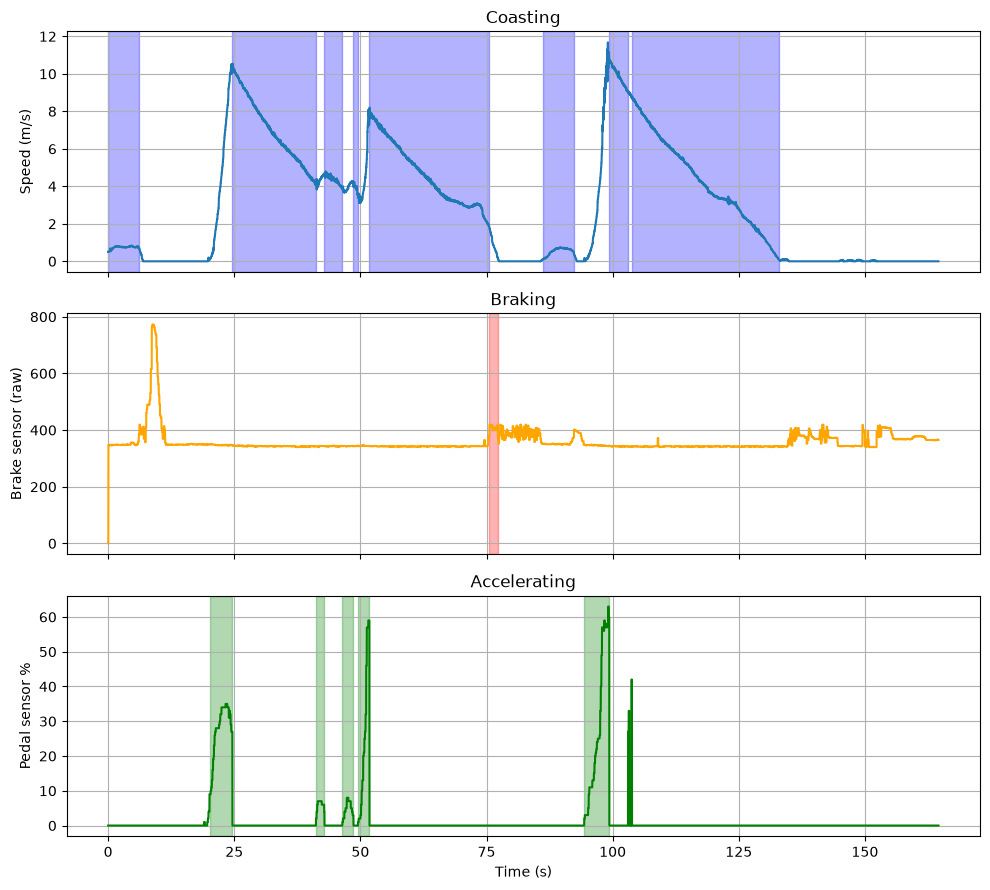

In [5]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 9))

axes[0].plot(time, speed, label="Speed (m/s)")
axes[0].set_ylabel("Speed (m/s)")
axes[0].grid(True)
axes[0].set_title("Coasting")
for s, e in zip(coasting_starts, coasting_ends):
    axes[0].axvspan(s, e, color='blue', alpha=0.3)

axes[1].plot(time, brake, label="Braking", color='orange')
axes[1].set_ylabel("Brake sensor (raw)")
axes[1].grid(True)
axes[1].set_title("Braking")
for s, e in zip(braking_starts, braking_ends):
    axes[1].axvspan(s, e, color='red', alpha=0.3)

axes[2].plot(time, pedal, label="Acceleration", color='green')
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Pedal sensor %")
axes[2].grid(True)
axes[2].set_title("Accelerating")
for s, e in zip(acc_starts, acc_ends):
    axes[2].axvspan(s, e, color='green', alpha=0.3)

plt.tight_layout()
plt.show()